In [31]:
words=open("names.csv",encoding="utf-8").read().splitlines()

In [32]:
import re

clean_words = []

for w in words:

    w = re.sub(r"[^A-Za-z\s'& -]", "", w)
    w = " ".join(w.split())
    if w:
        clean_words.append(w)

words = clean_words

In [33]:
words[:10]

['lavera',
 'fairytabs',
 'arkive',
 'gaa',
 'cultiv cosmetique',
 'the green recipe',
 'mlanine',
 'base cosmetics',
 'ose',
 'moon hudvrd']

In [34]:
len(words)

33631

In [35]:
min(len(w) for w in words)

1

In [36]:
max(len(w) for w in words)

99

BIGRAM

In [37]:
b={}
for w in words:
    chs=['<S>']+list(w)+['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram=(ch1,ch2)
        b[bigram]=b.get(bigram,0)+1
        



In [38]:
sorted(b.items(),key=lambda kv:-kv[1])

[(('e', ' '), 9277),
 ((' ', 's'), 8834),
 (('i', 'n'), 8513),
 (('t', 'i'), 8339),
 (('c', 'o'), 8312),
 (('a', 'l'), 8156),
 ((' ', 'c'), 7842),
 (('o', 'n'), 7571),
 (('s', ' '), 7426),
 (('a', 'r'), 7288),
 (('i', 'c'), 6970),
 (('e', 'r'), 6740),
 (('a', 'n'), 6336),
 (('o', 's'), 6210),
 (('m', 'e'), 6158),
 (('a', ' '), 6154),
 ((' ', 'l'), 5945),
 (('y', ' '), 5826),
 ((' ', 'b'), 5815),
 (('s', '<E>'), 5690),
 (('r', 'e'), 5372),
 (('b', 'e'), 5276),
 (('e', 's'), 5237),
 (('e', 'a'), 5187),
 (('m', 'a'), 5178),
 (('n', ' '), 5172),
 (('e', 't'), 5139),
 (('l', 'o'), 5105),
 (('h', 'a'), 4968),
 (('s', 'a'), 4917),
 (('u', 't'), 4880),
 (('r', 'a'), 4775),
 (('r', ' '), 4737),
 (('t', 'e'), 4691),
 (('s', 't'), 4518),
 (('n', 'a'), 4467),
 (('s', 'm'), 4455),
 (('l', 'i'), 4426),
 (('a', 'i'), 4376),
 (('o', 'r'), 4315),
 (('l', 'a'), 4239),
 (('e', 'n'), 4235),
 (('a', 'u'), 4080),
 (('t', 'y'), 4026),
 (('r', 'i'), 3857),
 (('i', 'o'), 3798),
 (('<S>', 's'), 3727),
 (('a', '

In [39]:
import torch

In [40]:
N=torch.zeros((31,31),dtype=torch.int32)

In [41]:
chars=sorted(list(set(' '.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0

In [42]:

for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2]+=1

In [43]:
N

tensor([[   0,    0,    0,    3,    8, 2478, 2803, 2367, 1487, 1366, 1256, 1086,
         1475,  880,  632,  926, 2089, 2271, 1325,  675, 1945,  120, 1042, 3727,
         1718,  352,  652,  460,   61,  233,  194],
        [   0,    0, 1445,    6,  699, 2873, 5815, 7842, 3004, 1772, 1361, 1673,
         3044, 3167,  356,  761, 5945, 2486, 1733, 1232, 3692,   75,  989, 8834,
         1546,  671,  575,  561,   37,  289,  144],
        [   0, 1442,    0,    0,    0,   12,   23,   23,    8,    3,    2,   10,
            4,    2,    3,    3,    5,   14,    5,    3,    4,    0,    6,    7,
            5,    2,    0,    2,    0,    1,    2],
        [   5,   26,    0,    2,    0,   68,    7,    4,    7,   34,    1,    2,
            9,   11,    0,    1,   12,    7,   10,   34,    2,    0,    4,  423,
            3,    6,    0,    2,    0,    1,    2],
        [  18,  710,    0,    0,    3,   26,   43,   62,   26,   17,    9,   12,
           19,   17,    4,   24,   34,   33,   13,   13,   28, 

In [44]:
itos={i:s for s,i in stoi.items()}
itos

{1: ' ',
 2: '&',
 3: "'",
 4: '-',
 5: 'a',
 6: 'b',
 7: 'c',
 8: 'd',
 9: 'e',
 10: 'f',
 11: 'g',
 12: 'h',
 13: 'i',
 14: 'j',
 15: 'k',
 16: 'l',
 17: 'm',
 18: 'n',
 19: 'o',
 20: 'p',
 21: 'q',
 22: 'r',
 23: 's',
 24: 't',
 25: 'u',
 26: 'v',
 27: 'w',
 28: 'x',
 29: 'y',
 30: 'z',
 0: '.'}

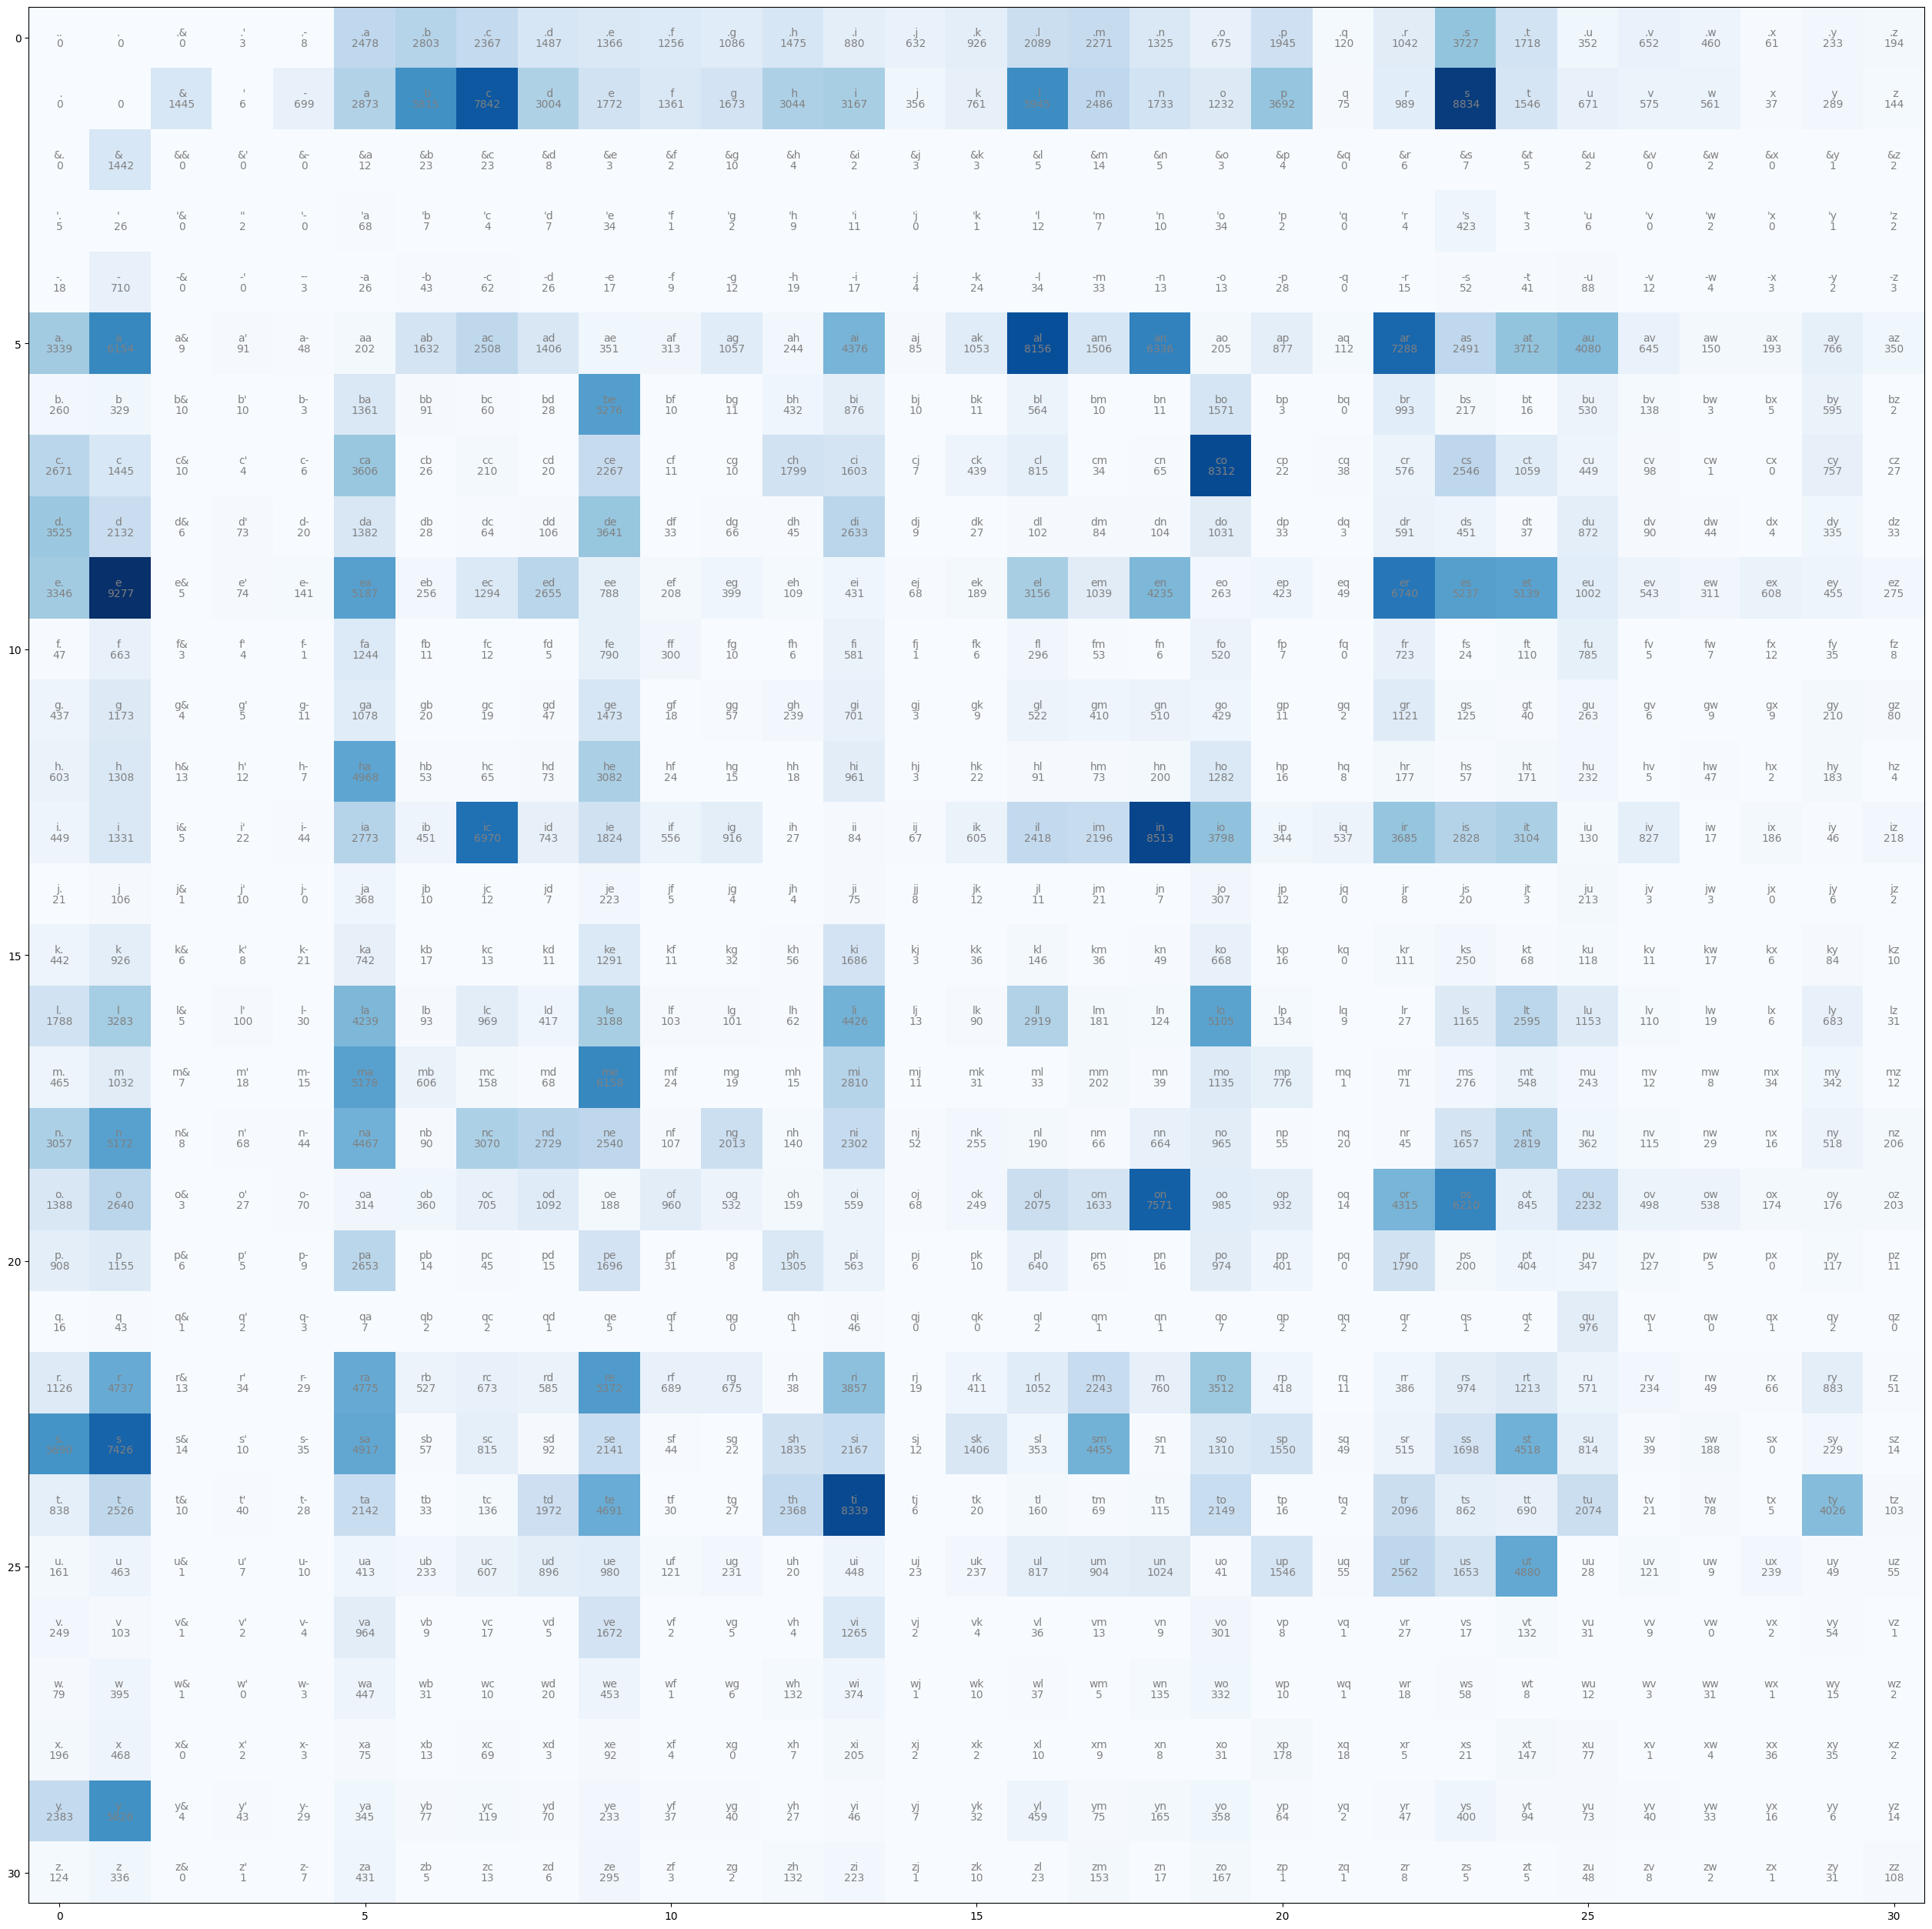

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(32,32))
plt.imshow(N,cmap='Blues')
for i in range(31):
    for j in range(31):
        chstr=itos[i]+itos[j]
        plt.text(j,i,chstr,ha="center",va="bottom",color='gray')
        plt.text(j,i,N[i,j].item(),ha="center",va="top",color="gray")





In [52]:
P=(N+1).float() #laplace smoothing since xz->0 gives loss->inf
P/=P.sum(1,keepdims=True) #keepdim must be true (brodcasting bug)  inplace operation to improve speed and not waste memory

In [53]:
g=torch.Generator().manual_seed(2178908907)
for i in range(10):
    ix=0
    out=[]
    while True:
        # p=N[ix].float() #the step is redundant. therefore we make a matrix already having probabilities
        # p=p/p.sum()
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

aeraliauiz.
kicso- naic.
batroudralitysckg inmphtud shaag.
p be so pais.
ltarvishorelcaty.
lsar- td.
mindrt.
fetr m llsmet tin.
io.
tenameatoroucosedearon biminar.


In [ ]:
log_likelihood=0
n=0
for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
       
        p=P[ix1,ix2]
        logprob=torch.log(p)
        log_likelihood+=logprob
        # print(ch1,ch2,p,logprob)
        n+=1

# print(f'{logprob}')
nll=-log_likelihood
# print(f'{nll}')
print(f'{nll/n}')  #quality of our training

5.178340435028076


NEURAL NETS

In [60]:
xs=[]
ys=[]
for w in words[:1]:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs=torch.tensor(xs)
ys=torch.tensor(ys)

print(xs)
print(ys)

tensor([ 0, 16,  5, 26,  9, 22,  5])
tensor([16,  5, 26,  9, 22,  5,  0])


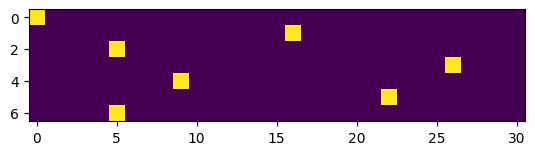

In [74]:
plt.imshow(xenc)

In [ ]:
#we need to encode them using one hot encoding where in if xs=10 then the 10th bit is set to 1
import torch.nn.functional as F
xenc=F.one_hot(xs,num_classes=31).float() #num_classes is the length of the tensor also need to convert it to float because xenc.dtype=int64
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]

In [73]:
xenc.dtype

torch.float32

In [90]:
w=torch.randn(31,31,requires_grad=True)
xenc@w



tensor([[-0.4774,  1.5525, -1.1197, -2.0280,  0.1351, -1.2366, -0.8330,  1.3279,
          0.6366,  0.2829, -1.7027,  0.5353,  0.5615,  0.6657, -1.1750, -1.2622,
          1.3509, -0.7694, -0.5029,  1.2382, -0.3479, -1.2622,  0.8564,  1.1854,
          0.3025,  0.5816,  1.1624, -0.6685,  0.6502,  0.8007,  0.8540],
        [ 0.5074,  0.8408, -0.1310, -0.0818, -1.3334, -0.1521, -0.7581,  0.3816,
         -0.5132,  0.0365, -0.5649,  0.3171, -0.9155, -0.3027, -0.1395, -0.0437,
          2.5433,  0.8479, -1.2204, -0.2440,  1.0113,  1.0115,  0.0994,  1.7699,
         -0.9062, -0.0532,  0.9591, -0.7271, -0.0719,  0.7734, -0.3440],
        [ 1.4072,  0.2651, -1.1645, -0.7398, -0.0800,  0.5293, -0.9303, -0.1356,
         -0.1365,  0.7666, -0.3209,  1.0360, -0.6467, -1.2984,  0.4677, -0.6549,
          2.6530, -0.4663,  0.7377,  0.0410, -1.2955,  0.7086, -0.6751,  0.1403,
         -0.2956,  0.2385, -0.6556, -1.7969, -1.9607, -1.2159, -0.1685],
        [ 0.4303,  1.9378,  0.0609, -0.9510, -0.0829

In [100]:
logits=xenc@w 
count=logits.exp() #softmax line1
probs=count/count.sum(1,keepdims=True) #softmax lin2

In [92]:
nlls=torch.zeros(7)
for i in range (7):
    x=xs[i].item() #input character index
    y=ys[i].item() #output character index
    print('---------')

    print(f'bigram example {i+1} : {itos[x]}{itos[y] } (indexes {x},{y})')
    print('input to the nn : ',x)
    print('output probabilities of other char given input : ',probs[i])
    print('actual next character : ',y)
    p=probs[i,y]
    print('prob assigned by nn to correct output : ',p.item())
    logp=torch.log(p)
    print('log likelihood : ',logp)
    nll=-logp
    print('negative log likelihood : ',nll)
    nlls[i]=nll

print('====')
print('loss or average nll : ',nlls.mean())

---------
bigram example 1 : .l (indexes 0,16)
input to the nn :  0
output probabilities of other char given input :  tensor([0.0126, 0.0960, 0.0066, 0.0027, 0.0233, 0.0059, 0.0088, 0.0767, 0.0384,
        0.0270, 0.0037, 0.0347, 0.0357, 0.0396, 0.0063, 0.0058, 0.0785, 0.0094,
        0.0123, 0.0701, 0.0144, 0.0058, 0.0479, 0.0665, 0.0275, 0.0364, 0.0650,
        0.0104, 0.0390, 0.0453, 0.0478], grad_fn=<SelectBackward0>)
actual next character :  16
prob assigned by nn to correct output :  0.0785025954246521
log likelihood :  tensor(-2.5446, grad_fn=<LogBackward0>)
negative log likelihood :  tensor(2.5446, grad_fn=<NegBackward0>)
---------
bigram example 2 : la (indexes 16,5)
input to the nn :  16
output probabilities of other char given input :  tensor([0.0318, 0.0444, 0.0168, 0.0176, 0.0050, 0.0164, 0.0090, 0.0280, 0.0115,
        0.0199, 0.0109, 0.0263, 0.0077, 0.0141, 0.0167, 0.0183, 0.2435, 0.0447,
        0.0056, 0.0150, 0.0526, 0.0526, 0.0211, 0.1124, 0.0077, 0.0182, 0.0500,
   

In [101]:
loss=-probs[torch.arange(7),ys].log().mean()
loss

tensor(3.5451, grad_fn=<NegBackward0>)

In [98]:
w.grad=None
loss.backward()

In [99]:
w.data+=-0.1*w.grad